In [35]:
import yt
import numpy as np
from yt.mods import *
from yt.frontends.boxlib.api import NyxDataset, AMReXDataset
import matplotlib.pyplot as plt

In [78]:
#file1 = "../Outputs/plt00650"
#file1 = "../Outputs/SplitRef/plt00153"
file1 = "../plt00002"
#file1 = "../plt00000"

ds = AMReXDataset(file1)

yt : [INFO     ] 2022-09-29 16:14:44,902 Parameters: current_time              = 0.1
yt : [INFO     ] 2022-09-29 16:14:44,903 Parameters: domain_dimensions         = [128 128 128]
yt : [INFO     ] 2022-09-29 16:14:44,904 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2022-09-29 16:14:44,905 Parameters: domain_right_edge         = [30. 30. 30.]


In [88]:
#avInit = ds.all_data().quantities.weighted_average_quantity("Edens", weight = ("index", "ones"))
ad = ds.all_data()
ad.max_level=0
avE  = ad.quantities.weighted_average_quantity("Edens", weight = ("index", "ones"))
avG  = ad.quantities.weighted_average_quantity("Egrad", weight = ("index", "ones"))
avP  = ad.quantities.weighted_average_quantity("Epot", weight = ("index", "ones"))
avK  = ad.quantities.weighted_average_quantity("Ekin", weight = ("index", "ones"))


def _relField (field, data, name, av):
    return data[name]/av
def _relE(field,data):
    return _relField(field, data, "Edens", avE)
def _relEg(field,data):
    return _relField(field, data, "Egrad", avG)
def _relEp(field,data):
    return _relField(field, data, "Epot", avP)
def _relEk(field,data):
    return _relField(field, data, "Ekin", avK)

ds.add_field(("boxlib","EdensRel"), function=_relE, sampling_type="local", units="dimensionless", force_override=True)
ds.add_field(("boxlib","EgradRel"), function=_relEg, sampling_type="local", units="dimensionless", force_override=True)
ds.add_field(("boxlib","EpotRel"), function=_relEp, sampling_type="local", units="dimensionless", force_override=True)
ds.add_field(("boxlib","EkinRel"), function=_relEk, sampling_type="local", units="dimensionless", force_override=True)

In [89]:
ds.add_gradient_fields("KGfpr")

[('boxlib', 'KGfpr_gradient_x'),
 ('boxlib', 'KGfpr_gradient_y'),
 ('boxlib', 'KGfpr_gradient_z'),
 ('boxlib', 'KGfpr_gradient_magnitude')]

In [90]:
ds.force_periodicity()

In [91]:
ds.length_unit

unyt_quantity(1., 'cm')

In [94]:
def _gPerE(field,data):
    #return 0.000150796*data["KGfpr_gradient_magnitude"]*data["KGfpr_gradient_magnitude"]/(data["Epot"] + data["Ekin"] + 0.000150796*data["KGfpr_gradient_magnitude"]*data["KGfpr_gradient_magnitude"]/(data["KGfpr_gradient_magnitude"].units*data["KGfpr_gradient_magnitude"].units)) # The num is 8\pi/3/A^2
    return data["KGfpr_gradient_magnitude"]*data["KGfpr_gradient_magnitude"]/(data["KGfpr_gradient_magnitude"].units*data["KGfpr_gradient_magnitude"].units) - data["Egrad"]
#    return data["KGfpr_gradient_y"]*data["KGfpr_gradient_y"]/(data["KGfpr_gradient_y"].units*data["KGfpr_gradient_y"].units) - data["Egrad"]


ds.add_field(("boxlib","DiffGrad"), function=_gPerE, sampling_type="local", units="dimensionless", force_override=True)

yt : [INFO     ] 2022-09-29 16:19:18,394 xlim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 16:19:18,394 ylim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 16:19:18,395 xlim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 16:19:18,396 ylim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 16:19:18,397 Making a fixed resolution buffer of (('boxlib', 'DiffGrad')) 800 by 800
yt : [WARNING  ] 2022-09-29 16:19:18,498 Plotting ('boxlib', 'DiffGrad'): Both positive and negative values. Min = -5.065392549852422e-16 dimensionless, Max = 4.302114220422808e-16 dimensionless.
yt : [WARNING  ] 2022-09-29 16:19:18,498 Switching to symlog colorbar scaling.
yt : [INFO     ] 2022-09-29 16:19:18,604 Making a fixed resolution buffer of (('boxlib', 'DiffGrad')) 800 by 800



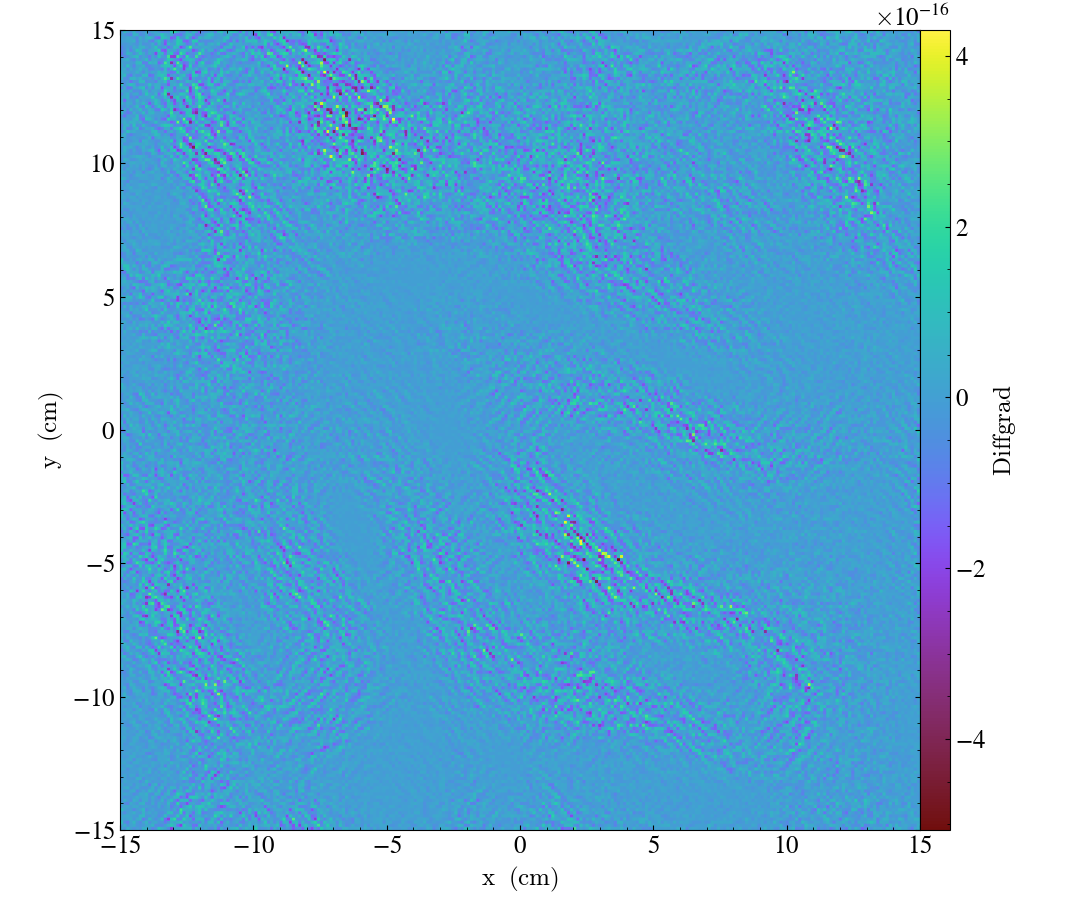

In [96]:
ad = ds.all_data()
ad.min_level=1
#ad.max_level=0

slc = yt.SlicePlot(ds, "z", "DiffGrad", data_source=ad)#, center = [0,0,0])

slc.zoom(1)
slc.set_log("DiffGrad", False)

#slc.annotate_grids()
slc.show()

yt : [INFO     ] 2022-09-29 15:17:48,623 xlim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 15:17:48,623 ylim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 15:17:48,624 xlim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 15:17:48,625 ylim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 15:17:48,626 Making a fixed resolution buffer of (('boxlib', 'KGfpr_gradient_magnitude')) 800 by 800



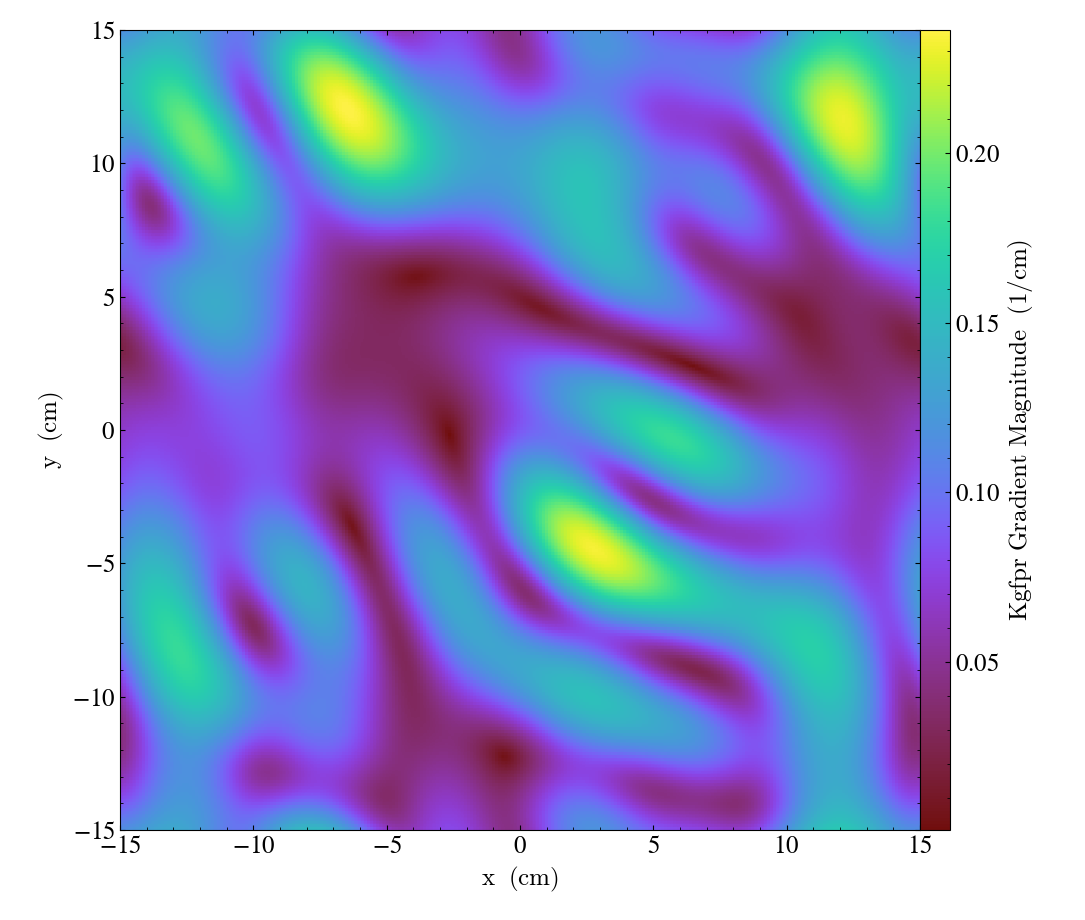

In [6]:
%matplotlib widget

ad = ds.all_data()
ad.min_level=1
#ad.max_level=0

slc = yt.SlicePlot(ds, "z", "KGfpr_gradient_magnitude", data_source=ad)#, center = [0,0,0])

slc.zoom(1)
slc.set_log("KGfpr", False)
slc.set_log("KGfpr_gradient_magnitude", False)

#slc.annotate_grids()
slc.show()

yt : [INFO     ] 2022-09-29 15:17:49,969 xlim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 15:17:49,970 ylim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 15:17:49,971 xlim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 15:17:49,971 ylim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 15:17:49,972 Making a fixed resolution buffer of (('boxlib', 'KGfpr_gradient_magnitude')) 800 by 800



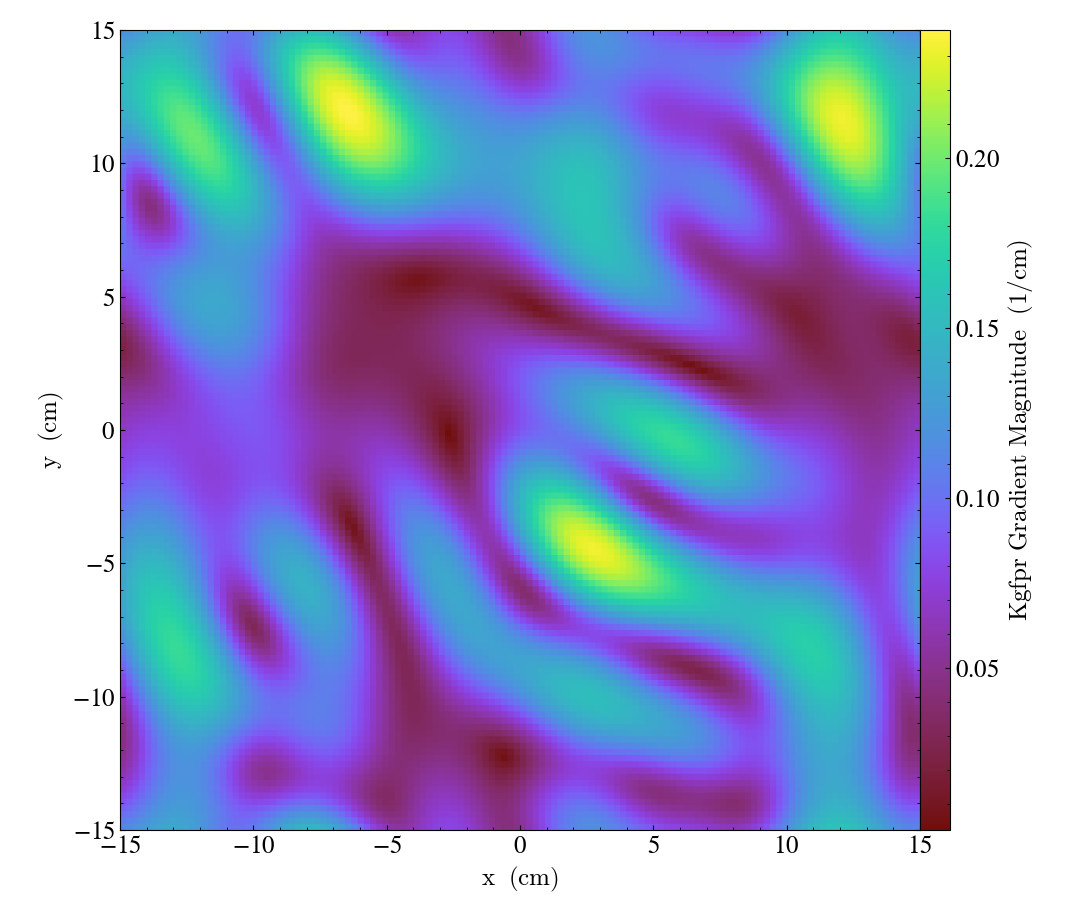

In [7]:
%matplotlib widget

ad = ds.all_data()
#ad.min_level=1
ad.max_level=0

slc = yt.SlicePlot(ds, "z", "KGfpr_gradient_magnitude", data_source=ad)#, center = [0,0,0])

slc.zoom(1)
slc.set_log("KGfpr_gradient_magnitude", False)

#slc.annotate_grids()
slc.show()

yt : [INFO     ] 2022-09-27 16:39:56,381 xlim = 0.000000 30.000000
yt : [INFO     ] 2022-09-27 16:39:56,382 ylim = 0.000000 30.000000
yt : [INFO     ] 2022-09-27 16:39:56,383 xlim = 0.000000 30.000000
yt : [INFO     ] 2022-09-27 16:39:56,384 ylim = 0.000000 30.000000
yt : [INFO     ] 2022-09-27 16:39:56,385 Making a fixed resolution buffer of (('boxlib', 'EpotRel')) 800 by 800



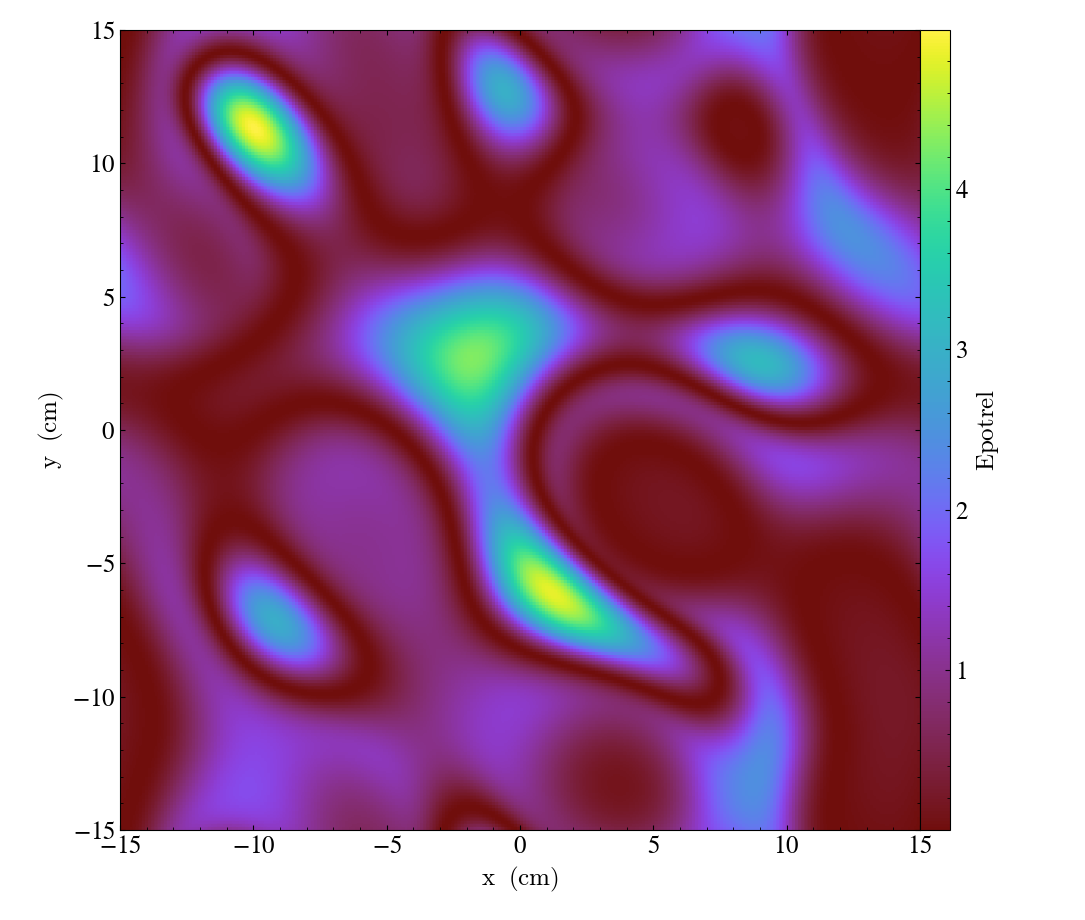

In [6]:
ad = ds.all_data()
ad.min_level=1
#ad.max_level=0

slc = yt.SlicePlot(ds, "z", "EpotRel", data_source=ad)#, center = [0,0,0])

slc.zoom(1)
slc.set_log("EpotRel", False)

#slc.annotate_grids()
slc.show()

yt : [INFO     ] 2022-09-27 16:39:57,311 xlim = 0.000000 30.000000
yt : [INFO     ] 2022-09-27 16:39:57,312 ylim = 0.000000 30.000000
yt : [INFO     ] 2022-09-27 16:39:57,313 xlim = 0.000000 30.000000
yt : [INFO     ] 2022-09-27 16:39:57,313 ylim = 0.000000 30.000000
yt : [INFO     ] 2022-09-27 16:39:57,314 Making a fixed resolution buffer of (('boxlib', 'EkinRel')) 800 by 800



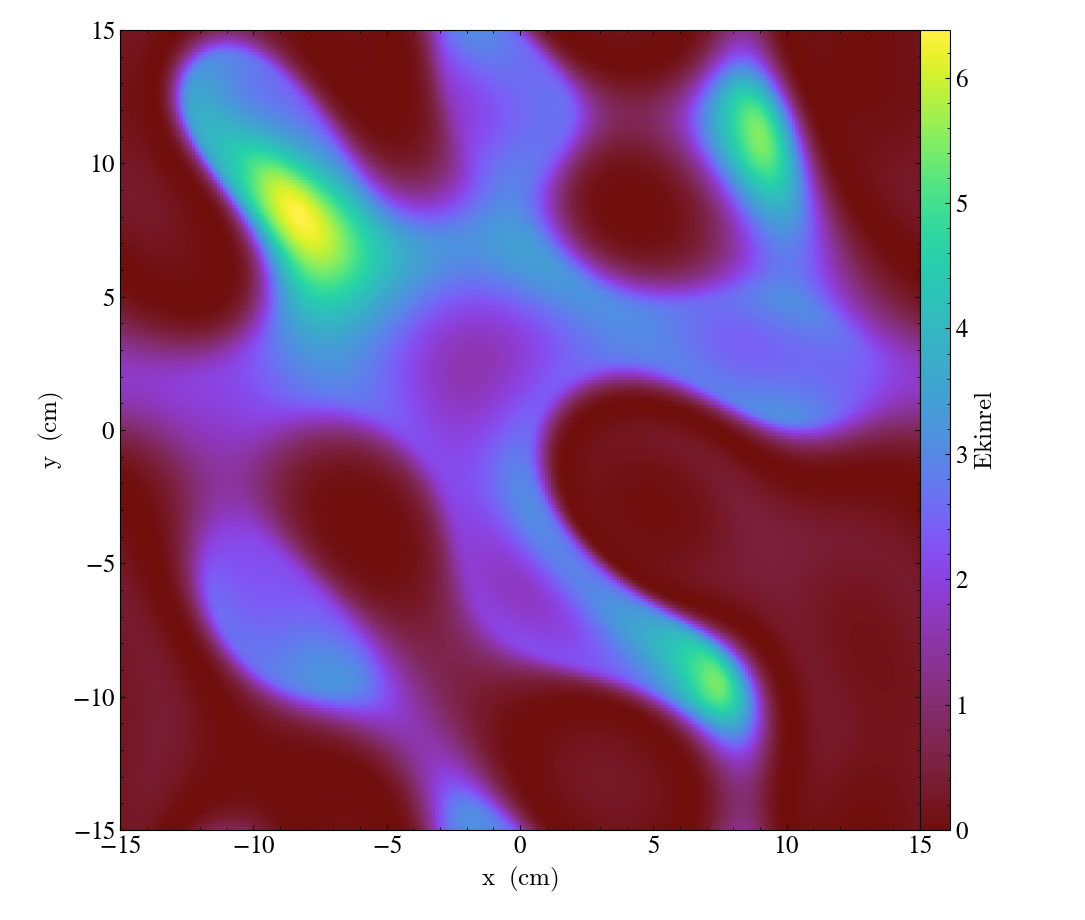

In [7]:
ad = ds.all_data()
ad.min_level=1
#ad.max_level=0

slc = yt.SlicePlot(ds, "z", "EkinRel", data_source=ad)#, center = [0,0,0])

slc.zoom(1)
slc.set_log("EkinRel", False)

#slc.annotate_grids()
slc.show()

yt : [INFO     ] 2022-09-29 16:07:20,029 xlim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 16:07:20,030 ylim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 16:07:20,031 xlim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 16:07:20,031 ylim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 16:07:20,033 Making a fixed resolution buffer of (('boxlib', 'Egrad')) 800 by 800
yt : [WARNING  ] 2022-09-29 16:07:20,086 Plotting ('boxlib', 'Egrad'): Both positive and negative values. Min = -0.15520871761355642 dimensionless, Max = 0.18480923972891586 dimensionless.
yt : [WARNING  ] 2022-09-29 16:07:20,087 Switching to symlog colorbar scaling.
yt : [INFO     ] 2022-09-29 16:07:20,192 Making a fixed resolution buffer of (('boxlib', 'Egrad')) 800 by 800



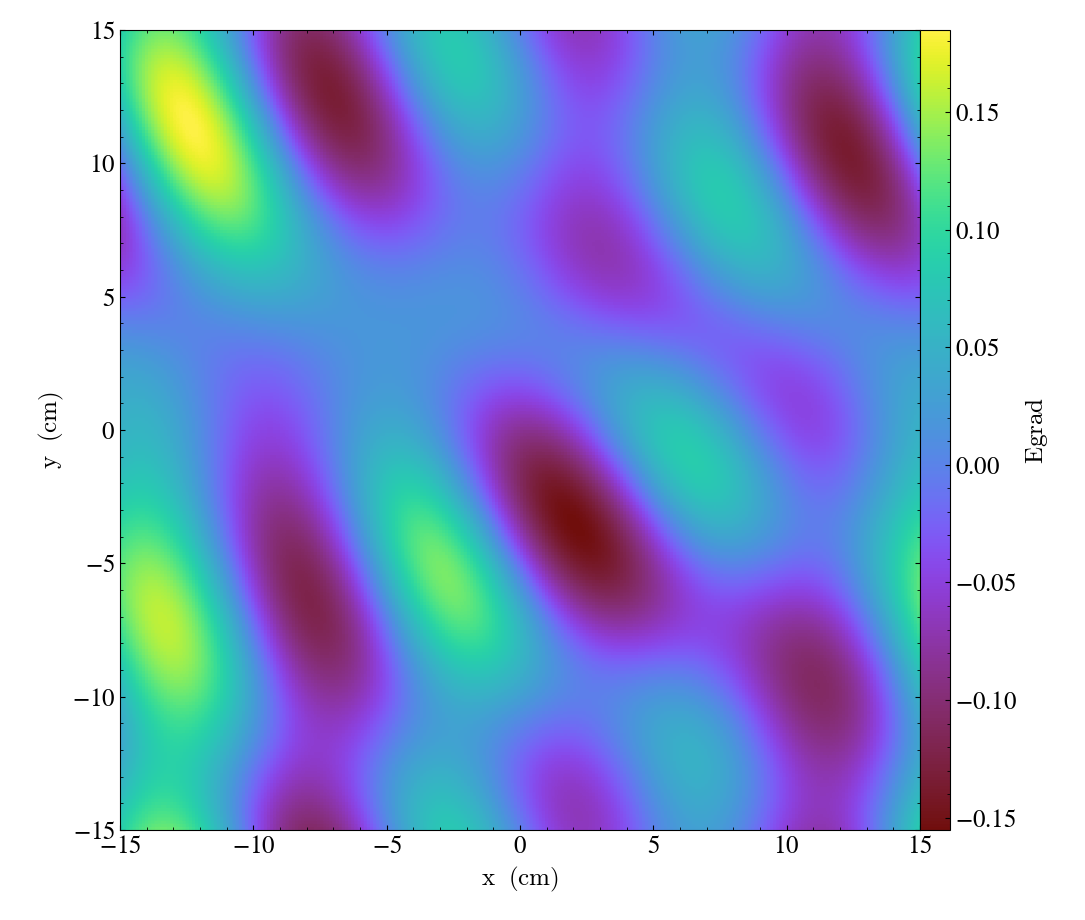

In [47]:
ad = ds.all_data()
ad.min_level=1
#ad.max_level=0

slc = yt.SlicePlot(ds, "z", "Egrad", data_source=ad)#, center = [0,0,0])

slc.zoom(1)
slc.set_log("Egrad", False)

#slc.annotate_grids()
slc.show()

yt : [INFO     ] 2022-09-29 16:07:27,283 xlim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 16:07:27,284 ylim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 16:07:27,285 xlim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 16:07:27,286 ylim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 16:07:27,287 Making a fixed resolution buffer of (('boxlib', 'KGfpr_gradient_x')) 800 by 800
yt : [WARNING  ] 2022-09-29 16:07:27,393 Plotting ('boxlib', 'KGfpr_gradient_x'): Both positive and negative values. Min = -0.15520871761355612 1/cm, Max = 0.18480923972891575 1/cm.
yt : [WARNING  ] 2022-09-29 16:07:27,393 Switching to symlog colorbar scaling.
yt : [INFO     ] 2022-09-29 16:07:27,506 Making a fixed resolution buffer of (('boxlib', 'KGfpr_gradient_x')) 800 by 800



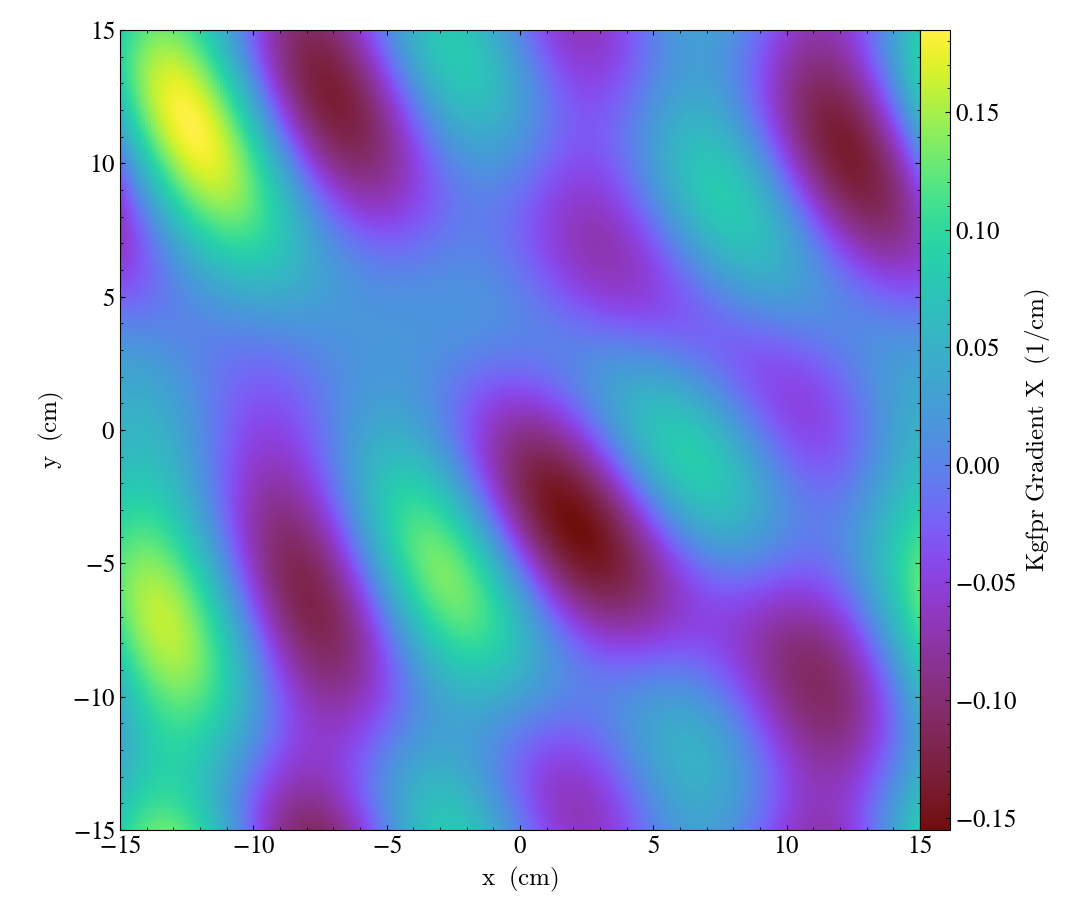

In [48]:
ad = ds.all_data()
ad.min_level=1
#ad.max_level=0

slc = yt.SlicePlot(ds, "z", "KGfpr_gradient_x", data_source=ad)#, center = [0,0,0])

slc.zoom(1)
slc.set_log("KGfpr_gradient_x", False)

#slc.annotate_grids()
slc.show()